# Knife Sharpness (Velocity + Acceleration + FFT Features)
Same preprocessing flow as the knife-sharpness notebook, now using Segment Velocity + Segment Acceleration with window-level FFT summary features.

In [9]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('d:/Swin documents/COS40007-Project/backend')

## Imports And Config

In [10]:
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from torch.utils.data import TensorDataset, DataLoader

from utils.seed import set_seed
from utils.device import get_device

seed = 42
device = get_device("auto")
set_seed(seed)

TARGET_COL = "sharpness_class"
WINDOW_SIZE = 60
WINDOW_STRIDE = 30
FRAME_SKIP_STEP = 1

n_splits = 10
batch_size = 32
num_epochs = 30
learning_rate = 1e-4
weight_decay = 1e-5
early_stopping_patience = 8

FFT_FRAME_RATE_HZ = 60.0
FFT_BANDS = ((0.5, 3.0), (3.0, 8.0), (8.0, 20.0))
FFT_EPS = 1e-12

print(f"[phase=setup] device={device}")
print(f"[phase=setup] FFT frame-rate={FFT_FRAME_RATE_HZ}Hz bands={FFT_BANDS}")

[phase=setup] device=cuda
[phase=setup] FFT frame-rate=60.0Hz bands=((0.5, 3.0), (3.0, 8.0), (8.0, 20.0))


## Read Velocity And Acceleration CSV

In [11]:
print("[phase=data] loading P1 + P2 datasets (velocity + acceleration)")
DATA_DIR = PROJECT_ROOT / "output_data"

source_files = [
    DATA_DIR / "P1_boning.csv",
    DATA_DIR / "P1_slicing.csv",
    DATA_DIR / "P2_boning.csv",
    DATA_DIR / "P2_slicing.csv",
]

missing_files = [str(p) for p in source_files if not p.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing source files: {missing_files}")

p1_raw_df = pd.concat(
    [
        pd.read_csv(DATA_DIR / "P1_boning.csv"),
        pd.read_csv(DATA_DIR / "P1_slicing.csv"),
    ],
    ignore_index=True,
)
p2_raw_df = pd.concat(
    [
        pd.read_csv(DATA_DIR / "P2_boning.csv"),
        pd.read_csv(DATA_DIR / "P2_slicing.csv"),
    ],
    ignore_index=True,
)

sensor_types = ["Segment Velocity", "Segment Acceleration"]
if "sensor_type" not in p1_raw_df.columns or "sensor_type" not in p2_raw_df.columns:
    raise KeyError("Missing required sensor_type column in source CSV files")

p1_raw_df = p1_raw_df[p1_raw_df["sensor_type"].isin(sensor_types)].copy()
p2_raw_df = p2_raw_df[p2_raw_df["sensor_type"].isin(sensor_types)].copy()


def detect_base_feature_columns(df):
    axis_regex = re.compile(r"\s([xyz])$")
    detected = [c for c in df.columns if axis_regex.search(str(c))]

    if len(detected) == 0:
        excluded = {
            "video_id",
            "Frame",
            "Label",
            "person_id",
            "activity_type",
            "knife_sharpness_score",
            "sensor_type",
        }
        numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        detected = [c for c in numeric_cols if c not in excluded]

    detected = sorted(list(dict.fromkeys(detected)))
    if len(detected) == 0:
        raise ValueError("No base feature columns were detected for velocity/acceleration merge")
    return detected


def merge_velocity_and_acceleration(df):
    vel_df = df[df["sensor_type"].astype(str).eq("Segment Velocity")].copy()
    acc_df = df[df["sensor_type"].astype(str).eq("Segment Acceleration")].copy()

    if vel_df.empty or acc_df.empty:
        raise ValueError("Both Segment Velocity and Segment Acceleration rows are required")

    base_cols = detect_base_feature_columns(vel_df)

    required_merge_cols = ["video_id", "Frame"]
    for merge_col in required_merge_cols:
        if merge_col not in vel_df.columns or merge_col not in acc_df.columns:
            raise KeyError(f"Missing merge column: {merge_col}")

    id_cols = [
        c
        for c in ["video_id", "Frame", "Label", "person_id", "activity_type", "knife_sharpness_score"]
        if c in vel_df.columns
    ]

    vel_df = vel_df[id_cols + base_cols].rename(columns={c: f"{c}_vel" for c in base_cols})
    acc_df = acc_df[required_merge_cols + base_cols].rename(columns={c: f"{c}_acc" for c in base_cols})

    merged_df = vel_df.merge(
        acc_df,
        on=required_merge_cols,
        how="inner",
        validate="one_to_one",
    )
    return merged_df, base_cols


p1_df, base_feature_cols = merge_velocity_and_acceleration(p1_raw_df)
p2_df, _ = merge_velocity_and_acceleration(p2_raw_df)

combined_df = pd.concat([p1_df, p2_df], ignore_index=True)

velocity_feature_cols = [f"{c}_vel" for c in base_feature_cols]
acceleration_feature_cols = [f"{c}_acc" for c in base_feature_cols]
feature_cols = velocity_feature_cols + acceleration_feature_cols

raw_video_ids = sorted(
    pd.concat([p1_raw_df, p2_raw_df], ignore_index=True)["video_id"]
    .dropna()
    .astype(str)
    .str.lower()
    .unique()
    .tolist()
)
merged_video_ids = sorted(
    combined_df["video_id"]
    .dropna()
    .astype(str)
    .str.lower()
    .unique()
    .tolist()
)
dropped_video_ids = sorted(set(raw_video_ids) - set(merged_video_ids))

print(f"[phase=data] p1_rows={len(p1_df)} p2_rows={len(p2_df)} total_rows={len(combined_df)}")
print(
    f"[phase=data] velocity_features={len(velocity_feature_cols)} "
    f"acceleration_features={len(acceleration_feature_cols)} total_features={len(feature_cols)}"
)
print(f"[phase=data] raw_unique_videos={len(raw_video_ids)} merged_unique_videos={len(merged_video_ids)}")
if dropped_video_ids:
    print(f"[phase=data][warning] videos dropped by inner merge: {dropped_video_ids}")
print("[phase=data] sample merged features:", feature_cols[:6])

[phase=data] loading P1 + P2 datasets (velocity + acceleration)


C:\Users\PCPV\AppData\Local\Temp\ipykernel_28472\536314575.py:17: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(DATA_DIR / "P1_boning.csv"),
C:\Users\PCPV\AppData\Local\Temp\ipykernel_28472\536314575.py:18: DtypeWarning: Columns (70) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(DATA_DIR / "P1_slicing.csv"),


[phase=data] p1_rows=266924 p2_rows=263369 total_rows=530293
[phase=data] velocity_features=69 acceleration_features=69 total_features=138
[phase=data] raw_unique_videos=26 merged_unique_videos=26
[phase=data] sample merged features: ['Head x_vel', 'Head y_vel', 'Head z_vel', 'L3 x_vel', 'L3 y_vel', 'L3 z_vel']


## Relabel And Build Knife Sharpness Target

In [12]:
print("[phase=data] Cleaning labels and filtering rows for knife-sharpness training")

label_mapping = {
    "0- Idle": 0,
    "0 - Idle": 0,
    "1- Walking": 1,
    "1 - Walking": 1,
    "2- Steeling": 2,
    "2 - Steeling": 2,
    "3- Reaching": 3,
    "3 - Reaching": 3,
    "4- Cutting": 4,
    "4 - Cutting": 4,
    "4 - Cutting (Big Pieces)": 4,
    "4 - Cutting (Big Piece)": 4,
    "4- Cutting (big piece)": 4,
    "4 - Cutting (offloading bone from Carcass)": 4,
    "5- Dropping": 8,
    "5 - Dropping": 8,
    "5 - Slicing": 5,
    "6 - Pulling": 6,
    "7 - Placing/ Manipulating": 7,
    "8 - Dropping": 8,
}

combined_df["Label"] = combined_df["Label"].replace(label_mapping)
combined_df["Label"] = pd.to_numeric(combined_df["Label"], errors="coerce")

if "activity_type" in combined_df.columns:
    boning_mask = combined_df["activity_type"].astype(str).str.lower().eq("boning")
    combined_df.loc[boning_mask & (combined_df["Label"] == 5), "Label"] = 8

invalid_label_count = int(combined_df["Label"].isna().sum())
if invalid_label_count > 0:
    print(f"[warning] dropping {invalid_label_count} rows with invalid labels")
    combined_df = combined_df.loc[combined_df["Label"].notna()].copy()
combined_df["Label"] = combined_df["Label"].astype("int64")

EXCLUDED_LABELS = {0, 1, 2, 3, 6, 7, 8}
combined_df = combined_df[~combined_df["Label"].isin(EXCLUDED_LABELS)].copy()

if "knife_sharpness_score" not in combined_df.columns:
    raise KeyError("Missing knife_sharpness_score column")

sharpness_score = pd.to_numeric(combined_df["knife_sharpness_score"], errors="coerce")
invalid_score_count = int(sharpness_score.isna().sum())
if invalid_score_count > 0:
    print(f"[warning] dropping {invalid_score_count} rows with invalid knife_sharpness_score")
    combined_df = combined_df.loc[sharpness_score.notna()].copy()
    sharpness_score = sharpness_score.loc[sharpness_score.notna()]

combined_df[TARGET_COL] = np.where(
    sharpness_score < 70,
    "blunt",
    np.where(sharpness_score >= 85, "sharp", "medium"),
)
combined_df[TARGET_COL] = combined_df[TARGET_COL].astype(str).str.strip().str.lower()

combined_df["Frame"] = pd.to_numeric(combined_df["Frame"], errors="coerce")
combined_df[feature_cols] = combined_df[feature_cols].apply(pd.to_numeric, errors="coerce")

required_cols = ["video_id", "Frame", TARGET_COL] + feature_cols
before_drop = len(combined_df)
combined_df = combined_df.dropna(subset=required_cols).copy()
after_drop = len(combined_df)
if after_drop < before_drop:
    print(f"[phase=data] dropped {before_drop - after_drop} rows with missing required values")

combined_df["Frame"] = combined_df["Frame"].astype(int)

assert len(combined_df) > 0, "No rows left after filtering"
assert combined_df[TARGET_COL].nunique() > 1, "Need at least 2 sharpness classes"

print(f"[phase=data] remaining rows={len(combined_df)}")
print(f"[phase=data] unique videos={combined_df['video_id'].nunique()}")
print(f"[phase=data] class labels={sorted(combined_df[TARGET_COL].unique().tolist())}")
print(combined_df[TARGET_COL].value_counts().to_string())

print("[phase=features] Building time-domain engineered features from velocity + acceleration")

segment_names = []
for col in base_feature_cols:
    if " " not in col:
        continue
    segment_name, axis = col.rsplit(" ", 1)
    if axis == "x":
        segment_names.append(segment_name)
segment_names = list(dict.fromkeys(segment_names))
if len(segment_names) == 0:
    raise ValueError("No segment names detected from base_feature_cols")


def get_series_or_zero(col_name):
    if col_name in combined_df.columns:
        return pd.to_numeric(combined_df[col_name], errors="coerce").fillna(0.0)
    return pd.Series(np.zeros(len(combined_df), dtype=np.float64), index=combined_df.index)


engineered_cols = {}
for seg in segment_names:
    vx = get_series_or_zero(f"{seg} x_vel")
    vy = get_series_or_zero(f"{seg} y_vel")
    vz = get_series_or_zero(f"{seg} z_vel")
    ax = get_series_or_zero(f"{seg} x_acc")
    ay = get_series_or_zero(f"{seg} y_acc")
    az = get_series_or_zero(f"{seg} z_acc")

    engineered_cols[f"{seg}_vel_mag"] = np.sqrt(vx ** 2 + vy ** 2 + vz ** 2)
    engineered_cols[f"{seg}_acc_mag"] = np.sqrt(ax ** 2 + ay ** 2 + az ** 2)

velocity_mag_feature_cols = [f"{seg}_vel_mag" for seg in segment_names]
acceleration_mag_feature_cols = [f"{seg}_acc_mag" for seg in segment_names]

energy_cols = [c for c in (velocity_feature_cols + acceleration_feature_cols) if c in combined_df.columns]
engineered_cols["total_body_energy"] = combined_df[energy_cols].pow(2).sum(axis=1)

arm_joints = [
    seg
    for seg in segment_names
    if any(k in seg for k in ["Shoulder", "Upper Arm", "Forearm", "Hand"])
]
leg_joints = [
    seg
    for seg in segment_names
    if any(k in seg for k in ["Upper Leg", "Lower Leg", "Foot", "Toe"])
]
spine_head_joints = [
    seg for seg in segment_names if seg in ["L5", "L3", "T12", "T8", "Neck", "Head"]
]
upper_body_joints = list(dict.fromkeys(spine_head_joints + arm_joints))
lower_body_joints = leg_joints
left_body_joints = [seg for seg in segment_names if seg.startswith("Left ")]
right_body_joints = [seg for seg in segment_names if seg.startswith("Right ")]
left_arm_joints = [seg for seg in arm_joints if seg.startswith("Left ")]
right_arm_joints = [seg for seg in arm_joints if seg.startswith("Right ")]


def group_energy(df, joints):
    if len(joints) == 0:
        return pd.Series(np.zeros(len(df), dtype=np.float64), index=df.index)

    cols = []
    for seg in joints:
        cols.extend(
            [
                f"{seg} x_vel",
                f"{seg} y_vel",
                f"{seg} z_vel",
                f"{seg} x_acc",
                f"{seg} y_acc",
                f"{seg} z_acc",
            ]
        )
    cols = [c for c in cols if c in df.columns]
    if len(cols) == 0:
        return pd.Series(np.zeros(len(df), dtype=np.float64), index=df.index)
    return df[cols].pow(2).sum(axis=1)


def group_component_abs_mean(df, joints, suffix):
    if len(joints) == 0:
        return pd.Series(np.zeros(len(df), dtype=np.float64), index=df.index)

    cols = []
    for seg in joints:
        cols.extend([f"{seg} x_{suffix}", f"{seg} y_{suffix}", f"{seg} z_{suffix}"])
    cols = [c for c in cols if c in df.columns]
    if len(cols) == 0:
        return pd.Series(np.zeros(len(df), dtype=np.float64), index=df.index)
    return df[cols].abs().mean(axis=1)


def frame_ordered_video_diff(series):
    temp = pd.DataFrame(
        {
            "video_id": combined_df["video_id"],
            "Frame": combined_df["Frame"],
            "value": pd.to_numeric(series, errors="coerce").fillna(0.0),
        },
        index=combined_df.index,
    ).sort_values(["video_id", "Frame"])
    temp["value_diff"] = temp.groupby("video_id")["value"].diff().fillna(0.0)
    return temp["value_diff"].reindex(combined_df.index).fillna(0.0)


upper_energy = group_energy(combined_df, upper_body_joints)
lower_energy = group_energy(combined_df, lower_body_joints)
left_energy = group_energy(combined_df, left_body_joints)
right_energy = group_energy(combined_df, right_body_joints)

engineered_cols["upper_body_energy"] = upper_energy
engineered_cols["lower_body_energy"] = lower_energy
engineered_cols["left_body_energy"] = left_energy
engineered_cols["right_body_energy"] = right_energy

eps = 1e-8
ul_denom = upper_energy + lower_energy + eps
lr_denom = left_energy + right_energy + eps

engineered_cols["upper_energy_ratio"] = upper_energy / ul_denom
engineered_cols["lower_energy_ratio"] = lower_energy / ul_denom
engineered_cols["left_energy_ratio"] = left_energy / lr_denom
engineered_cols["right_energy_ratio"] = right_energy / lr_denom

energy_distribution_feature_cols = [
    "upper_energy_ratio",
    "lower_energy_ratio",
    "left_energy_ratio",
    "right_energy_ratio",
]

jerk_feature_cols = []
total_jerk_terms = []
upper_jerk_terms = []
lower_jerk_terms = []
for seg in segment_names:
    jx = frame_ordered_video_diff(get_series_or_zero(f"{seg} x_acc"))
    jy = frame_ordered_video_diff(get_series_or_zero(f"{seg} y_acc"))
    jz = frame_ordered_video_diff(get_series_or_zero(f"{seg} z_acc"))

    jerk_mag_col = f"{seg}_jerk_mag"
    jerk_mag = np.sqrt(jx ** 2 + jy ** 2 + jz ** 2)
    engineered_cols[jerk_mag_col] = jerk_mag
    jerk_feature_cols.append(jerk_mag_col)

    jerk_sq = jerk_mag ** 2
    total_jerk_terms.append(jerk_sq)
    if seg in upper_body_joints:
        upper_jerk_terms.append(jerk_sq)
    if seg in lower_body_joints:
        lower_jerk_terms.append(jerk_sq)

total_jerk_energy = pd.Series(np.sum(np.column_stack(total_jerk_terms), axis=1), index=combined_df.index)
if len(upper_jerk_terms) > 0:
    upper_jerk_energy = pd.Series(np.sum(np.column_stack(upper_jerk_terms), axis=1), index=combined_df.index)
else:
    upper_jerk_energy = pd.Series(np.zeros(len(combined_df), dtype=np.float64), index=combined_df.index)
if len(lower_jerk_terms) > 0:
    lower_jerk_energy = pd.Series(np.sum(np.column_stack(lower_jerk_terms), axis=1), index=combined_df.index)
else:
    lower_jerk_energy = pd.Series(np.zeros(len(combined_df), dtype=np.float64), index=combined_df.index)

engineered_cols["upper_jerk_energy"] = upper_jerk_energy
engineered_cols["lower_jerk_energy"] = lower_jerk_energy
engineered_cols["global_smoothness"] = 1.0 / (1.0 + np.sqrt(total_jerk_energy + eps))
jerk_feature_cols.extend(["upper_jerk_energy", "lower_jerk_energy", "global_smoothness"])

arm_acc_mean = group_component_abs_mean(combined_df, arm_joints, "acc")
arm_vel_mean = group_component_abs_mean(combined_df, arm_joints, "vel")
leg_acc_mean = group_component_abs_mean(combined_df, leg_joints, "acc")
leg_vel_mean = group_component_abs_mean(combined_df, leg_joints, "vel")

engineered_cols["arm_abruptness_ratio"] = arm_acc_mean / (arm_vel_mean + eps)
engineered_cols["leg_abruptness_ratio"] = leg_acc_mean / (leg_vel_mean + eps)
abruptness_feature_cols = ["arm_abruptness_ratio", "leg_abruptness_ratio"]

left_arm_energy = group_energy(combined_df, left_arm_joints)
right_arm_energy = group_energy(combined_df, right_arm_joints)
trunk_energy = group_energy(combined_df, spine_head_joints)

engineered_cols["arm_energy_asymmetry"] = np.abs(left_arm_energy - right_arm_energy) / (
    left_arm_energy + right_arm_energy + eps
)
engineered_cols["trunk_compensation_ratio"] = trunk_energy / (upper_energy + eps)
asymmetry_feature_cols = ["arm_energy_asymmetry", "trunk_compensation_ratio"]


def velocity_alignment(df, seg_a, seg_b):
    required_cols = [
        f"{seg_a} x_vel",
        f"{seg_a} y_vel",
        f"{seg_a} z_vel",
        f"{seg_b} x_vel",
        f"{seg_b} y_vel",
        f"{seg_b} z_vel",
    ]
    if not all(c in df.columns for c in required_cols):
        return pd.Series(np.zeros(len(df), dtype=np.float64), index=df.index)

    a = df[[f"{seg_a} x_vel", f"{seg_a} y_vel", f"{seg_a} z_vel"]].to_numpy(dtype=np.float64)
    b = df[[f"{seg_b} x_vel", f"{seg_b} y_vel", f"{seg_b} z_vel"]].to_numpy(dtype=np.float64)
    dot = np.sum(a * b, axis=1)
    a_norm = np.linalg.norm(a, axis=1)
    b_norm = np.linalg.norm(b, axis=1)
    cos = dot / (a_norm * b_norm + eps)
    return pd.Series(np.clip(cos, -1.0, 1.0), index=df.index)


coordination_feature_cols = []
for side in ["Left", "Right"]:
    hand_seg = f"{side} Hand"
    forearm_seg = f"{side} Forearm"
    feature_name = f"{side.lower()}_hand_forearm_alignment"
    engineered_cols[feature_name] = velocity_alignment(combined_df, hand_seg, forearm_seg)
    coordination_feature_cols.append(feature_name)

engineered_df = pd.DataFrame(engineered_cols, index=combined_df.index)
overlap_cols = [c for c in engineered_df.columns if c in combined_df.columns]
if overlap_cols:
    combined_df = combined_df.drop(columns=overlap_cols)
combined_df = pd.concat([combined_df, engineered_df], axis=1)
combined_df = combined_df.loc[:, ~combined_df.columns.duplicated(keep="last")].copy()

engineered_feature_cols = (
    velocity_mag_feature_cols
    + acceleration_mag_feature_cols
    + ["total_body_energy"]
    + energy_distribution_feature_cols
    + jerk_feature_cols
    + abruptness_feature_cols
    + asymmetry_feature_cols
    + coordination_feature_cols
)
feature_cols = velocity_feature_cols + acceleration_feature_cols + engineered_feature_cols
fft_source_feature_cols = velocity_mag_feature_cols + acceleration_mag_feature_cols

combined_df[feature_cols] = combined_df[feature_cols].replace([np.inf, -np.inf], 0.0).fillna(0.0)

print(f"[phase=features] base vel+acc features={len(velocity_feature_cols) + len(acceleration_feature_cols)}")
print(f"[phase=features] engineered features={len(engineered_feature_cols)}")
print(f"[phase=features] total time-domain features={len(feature_cols)}")
print(f"[phase=features] FFT source features={len(fft_source_feature_cols)}")
print("[phase=features] sample final features:", feature_cols[:6], "...", feature_cols[-6:])

[phase=data] Cleaning labels and filtering rows for knife-sharpness training
[phase=data] remaining rows=325781
[phase=data] unique videos=26
[phase=data] class labels=['blunt', 'medium', 'sharp']
sharpness_class
sharp     148579
medium    121902
blunt      55300
[phase=features] Building time-domain engineered features from velocity + acceleration
[phase=features] base vel+acc features=138
[phase=features] engineered features=83
[phase=features] total time-domain features=221
[phase=features] FFT source features=46
[phase=features] sample final features: ['Head x_vel', 'Head y_vel', 'Head z_vel', 'L3 x_vel', 'L3 y_vel', 'L3 z_vel'] ... ['arm_abruptness_ratio', 'leg_abruptness_ratio', 'arm_energy_asymmetry', 'trunk_compensation_ratio', 'left_hand_forearm_alignment', 'right_hand_forearm_alignment']


## Build Contiguous Runs (Video + Frame Continuity)

In [13]:
combined_df = combined_df.sort_values(["video_id", "Frame"]).reset_index(drop=True)

# Knife sharpness is video-level; use one target per video.
video_target_map = combined_df.groupby("video_id")[TARGET_COL].agg(lambda s: s.iloc[0]).to_dict()

runs = []
frame_counts = {}
run_counts = {}
frame_gap_boundaries = 0

start_idx = 0
current_video = combined_df.loc[0, "video_id"]
current_target = video_target_map[current_video]

for i in range(len(combined_df)):
    target_i = video_target_map[combined_df.loc[i, "video_id"]]
    frame_counts[target_i] = frame_counts.get(target_i, 0) + 1

for i in range(1, len(combined_df)):
    video_i = combined_df.loc[i, "video_id"]
    prev_frame = int(combined_df.loc[i - 1, "Frame"])
    curr_frame = int(combined_df.loc[i, "Frame"])

    is_frame_gap = (curr_frame - prev_frame) != 1
    is_boundary = (video_i != current_video) or is_frame_gap

    if is_boundary:
        if video_i == current_video and is_frame_gap:
            frame_gap_boundaries += 1

        end_idx = i - 1
        runs.append({
            "video_id": current_video,
            "target": current_target,
            "start_idx": start_idx,
            "end_idx": end_idx,
            "start_frame": int(combined_df.loc[start_idx, "Frame"]),
            "end_frame": int(combined_df.loc[end_idx, "Frame"]),
            "run_length": int(end_idx - start_idx + 1)
        })

        run_counts[current_target] = run_counts.get(current_target, 0) + 1
        start_idx = i
        current_video = video_i
        current_target = video_target_map[current_video]

end_idx = len(combined_df) - 1
runs.append({
    "video_id": current_video,
    "target": current_target,
    "start_idx": start_idx,
    "end_idx": end_idx,
    "start_frame": int(combined_df.loc[start_idx, "Frame"]),
    "end_frame": int(combined_df.loc[end_idx, "Frame"]),
    "run_length": int(end_idx - start_idx + 1)
})
run_counts[current_target] = run_counts.get(current_target, 0) + 1

runs_df = pd.DataFrame(runs)

print(f"[phase=runs] total_runs={len(runs)}")
print(f"[phase=runs] frame-gap boundaries={frame_gap_boundaries}")
print(f"[phase=runs] frame count per {TARGET_COL}:")
for target in sorted(frame_counts):
    print(f"  {target}: {frame_counts[target]}")
print(f"[phase=runs] run count per {TARGET_COL}:")
for target in sorted(run_counts):
    print(f"  {target}: {run_counts[target]}")
print("[phase=runs] run length stats:")
print(runs_df['run_length'].describe(percentiles=[0.5]).to_string())

[phase=runs] total_runs=372
[phase=runs] frame-gap boundaries=346
[phase=runs] frame count per sharpness_class:
  blunt: 55300
  medium: 121902
  sharp: 148579
[phase=runs] run count per sharpness_class:
  blunt: 81
  medium: 143
  sharp: 148
[phase=runs] run length stats:
count     372.000000
mean      875.755376
std       763.506235
min        23.000000
50%       608.000000
max      4737.000000


## Build Windows (Time-Domain + FFT Summary Features)

In [14]:
X_windows = []
y_windows = []
window_meta = []
window_lengths = []

fft_feature_names = [
    "fft_peak_freq_mean",
    "fft_peak_freq_std",
    "fft_centroid_mean",
    "fft_entropy_mean",
    "fft_low_band_ratio",
    "fft_mid_band_ratio",
    "fft_high_band_ratio",
    "fft_log_power_mean",
]


def compute_fft_summary(fft_input, frame_rate_hz):
    if fft_input.ndim != 2 or fft_input.shape[1] == 0 or fft_input.shape[0] < 2:
        return np.zeros(len(fft_feature_names), dtype=np.float32)

    centered = fft_input - np.nanmean(fft_input, axis=0, keepdims=True)
    centered = np.nan_to_num(centered, nan=0.0, posinf=0.0, neginf=0.0)

    spectrum = np.fft.rfft(centered, axis=0)
    power = (np.abs(spectrum) ** 2).astype(np.float64)
    freqs = np.fft.rfftfreq(centered.shape[0], d=1.0 / frame_rate_hz)

    if power.shape[0] <= 1 or freqs.shape[0] <= 1:
        return np.zeros(len(fft_feature_names), dtype=np.float32)

    # Drop DC component so summary emphasizes motion instead of static offsets.
    power = power[1:, :]
    freqs = freqs[1:]
    if power.size == 0 or freqs.size == 0:
        return np.zeros(len(fft_feature_names), dtype=np.float32)

    total_power = power.sum(axis=0) + FFT_EPS
    peak_idx = np.argmax(power, axis=0)
    peak_freq = freqs[peak_idx]

    centroid = (freqs[:, None] * power).sum(axis=0) / total_power
    p_norm = power / total_power
    entropy = -(p_norm * np.log(p_norm + FFT_EPS)).sum(axis=0)

    band_ratios = []
    for low_hz, high_hz in FFT_BANDS:
        band_mask = (freqs >= low_hz) & (freqs < high_hz)
        if np.any(band_mask):
            band_ratio = power[band_mask, :].sum(axis=0) / total_power
            band_ratios.append(float(np.mean(band_ratio)))
        else:
            band_ratios.append(0.0)

    summary = np.array(
        [
            float(np.mean(peak_freq)),
            float(np.std(peak_freq)),
            float(np.mean(centroid)),
            float(np.mean(entropy)),
            float(band_ratios[0]),
            float(band_ratios[1]),
            float(band_ratios[2]),
            float(np.mean(np.log10(total_power + FFT_EPS))),
        ],
        dtype=np.float32,
    )
    return np.nan_to_num(summary, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def append_window(idx_chunk, run_idx, run):
    if len(idx_chunk) == 0:
        return

    window_df = combined_df.iloc[idx_chunk]
    time_window = window_df[feature_cols].to_numpy(dtype=np.float32)
    fft_input = window_df[fft_source_feature_cols].to_numpy(dtype=np.float32)

    fft_summary = compute_fft_summary(fft_input, frame_rate_hz=FFT_FRAME_RATE_HZ)
    fft_block = np.repeat(fft_summary[None, :], repeats=time_window.shape[0], axis=0).astype(np.float32)
    full_window = np.concatenate([time_window, fft_block], axis=1).astype(np.float32)

    X_windows.append(full_window)
    y_windows.append(run["target"])
    window_lengths.append(len(idx_chunk))
    window_meta.append(
        {
            "run_idx": run_idx,
            "video_id": run["video_id"],
            "target": run["target"],
            "start_frame": int(window_df["Frame"].iloc[0]),
            "end_frame": int(window_df["Frame"].iloc[-1]),
            "window_len": int(len(idx_chunk)),
        }
    )


for run_idx, run in enumerate(runs):
    run_indices = np.arange(run["start_idx"], run["end_idx"] + 1)
    sampled_indices = run_indices[::FRAME_SKIP_STEP]

    if len(sampled_indices) == 0:
        continue

    if len(sampled_indices) <= WINDOW_SIZE:
        append_window(sampled_indices, run_idx, run)
        continue

    starts = list(range(0, len(sampled_indices) - WINDOW_SIZE + 1, WINDOW_STRIDE))
    for start in starts:
        idx_chunk = sampled_indices[start:start + WINDOW_SIZE]
        append_window(idx_chunk, run_idx, run)

    last_covered = starts[-1] + WINDOW_SIZE
    if last_covered < len(sampled_indices):
        append_window(sampled_indices[last_covered:], run_idx, run)

if len(X_windows) == 0:
    raise ValueError("No windows were created")

y_windows = np.array(y_windows, dtype=object)
window_meta_df = pd.DataFrame(window_meta)
window_lengths_np = np.array(window_lengths)

count_by_target = window_meta_df["target"].value_counts().sort_index().to_dict()
time_feature_dim = int(len(feature_cols))
fft_feature_dim = int(len(fft_feature_names))
final_feature_dim = int(X_windows[0].shape[1])

print(f"[phase=windows] total_windows={len(X_windows)}")
print(f"[phase=windows] windows per {TARGET_COL}={count_by_target}")
print(f"[phase=windows] short_windows(<{WINDOW_SIZE})={int((window_lengths_np < WINDOW_SIZE).sum())}")
print(f"[phase=windows] window length min/median/max={window_lengths_np.min()}/{int(np.median(window_lengths_np))}/{window_lengths_np.max()}")
print(f"[phase=windows] time_feature_dim={time_feature_dim}")
print(f"[phase=windows] fft_feature_dim={fft_feature_dim}")
print(f"[phase=windows] final_feature_dim={final_feature_dim}")
print(f"[phase=windows] fft_features={fft_feature_names}")

[phase=windows] total_windows=10675
[phase=windows] windows per sharpness_class={'blunt': 1805, 'medium': 3990, 'sharp': 4880}
[phase=windows] short_windows(<60)=366
[phase=windows] window length min/median/max=1/60/60
[phase=windows] time_feature_dim=221
[phase=windows] fft_feature_dim=8
[phase=windows] final_feature_dim=229
[phase=windows] fft_features=['fft_peak_freq_mean', 'fft_peak_freq_std', 'fft_centroid_mean', 'fft_entropy_mean', 'fft_low_band_ratio', 'fft_mid_band_ratio', 'fft_high_band_ratio', 'fft_log_power_mean']


## Prepare 10-Fold StratifiedGroupKFold

In [15]:
def pad_windows(window_list, target_len=60):
    padded = []
    for arr in window_list:
        if arr.shape[0] == target_len:
            padded.append(arr)
        elif arr.shape[0] < target_len:
            pad_rows = target_len - arr.shape[0]
            pad_block = np.zeros((pad_rows, arr.shape[1]), dtype=arr.dtype)
            padded.append(np.vstack([arr, pad_block]))
        else:
            padded.append(arr[:target_len])
    return np.stack(padded, axis=0)

X_all = pad_windows(X_windows, target_len=WINDOW_SIZE).astype(np.float32)
groups = window_meta_df['video_id'].astype(str).to_numpy()

label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(y_windows).astype(np.int64)

unique_groups = np.unique(groups)
if len(unique_groups) < n_splits:
    raise ValueError(f"Need at least {n_splits} unique video groups, found {len(unique_groups)}")

cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
fold_splits = list(cv.split(X_all, y_all, groups=groups))

print(f"[phase=split] X_all shape={X_all.shape}")
print(f"[phase=split] y_all shape={y_all.shape}")
print(f"[phase=split] unique video groups={len(unique_groups)}")
print(f"[phase=split] classes={label_encoder.classes_.tolist()}")
print(f"[phase=split] total folds={len(fold_splits)}")

[phase=split] X_all shape=(10675, 60, 229)
[phase=split] y_all shape=(10675,)
[phase=split] unique video groups=26
[phase=split] classes=['blunt', 'medium', 'sharp']
[phase=split] total folds=10


## Model

In [16]:
class ActivityBiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.classifier(out)
        return out

input_size = X_all.shape[-1]
num_classes = len(label_encoder.classes_)
hidden_size = 64
num_layers = 1
dropout = 0.2

print(f"[phase=model] input_size={input_size} num_classes={num_classes}")

[phase=model] input_size=229 num_classes=3


## Train (Cross-Validation)

In [17]:
def accuracy_from_logits(logits, targets):
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).float().mean().item()

criterion = nn.CrossEntropyLoss()
cv_fold_metrics = []
oof_true = []
oof_pred = []

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits, start=1):
    print(f"\n[phase=cv] ===== Fold {fold_idx}/{len(fold_splits)} =====")

    X_train_fold = X_all[train_idx].copy()
    X_val_fold = X_all[val_idx].copy()
    y_train_fold = y_all[train_idx].copy()
    y_val_fold = y_all[val_idx].copy()

    train_groups = set(groups[train_idx].tolist())
    val_groups = set(groups[val_idx].tolist())
    overlap = train_groups.intersection(val_groups)
    assert len(overlap) == 0, f"Leakage in fold {fold_idx}: {overlap}"

    # Fold-safe scaling: fit on train fold only.
    n_features = X_train_fold.shape[-1]
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold.reshape(-1, n_features)).reshape(X_train_fold.shape).astype(np.float32)
    X_val_fold = scaler.transform(X_val_fold.reshape(-1, n_features)).reshape(X_val_fold.shape).astype(np.float32)

    X_train_t = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_fold, dtype=torch.long)
    X_val_t = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_t = torch.tensor(y_val_fold, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)

    model = ActivityBiLSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_classes=num_classes,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    best_val_loss = float("inf")
    best_val_acc = 0.0
    patience_counter = 0
    checkpoint_path = PROJECT_ROOT / "notebook" / f"best_lstm_sharpness_velacc_fft_fold_{fold_idx}.pt"

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0.0
        train_acc = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * xb.size(0)
            train_acc += accuracy_from_logits(logits, yb) * xb.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)

                val_loss += loss.item() * xb.size(0)
                val_acc += accuracy_from_logits(logits, yb) * xb.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc /= len(val_loader.dataset)
        scheduler.step(val_loss)

        print(f"Fold {fold_idx:02d} Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"[fold={fold_idx}] Early stopping triggered.")
                break

    if checkpoint_path.exists():
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    model.eval()
    fold_preds = []
    fold_targets = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            fold_preds.append(preds)
            fold_targets.append(yb.numpy())

    fold_preds = np.concatenate(fold_preds)
    fold_targets = np.concatenate(fold_targets)
    oof_pred.append(fold_preds)
    oof_true.append(fold_targets)

    cv_fold_metrics.append({
        "fold": fold_idx,
        "train_windows": int(len(train_idx)),
        "val_windows": int(len(val_idx)),
        "best_val_loss": float(best_val_loss),
        "best_val_acc": float(best_val_acc)
    })

cv_results_df = pd.DataFrame(cv_fold_metrics)
print("\n[phase=cv] Per-fold results:")
print(cv_results_df.to_string(index=False))
print("\n[phase=cv] Aggregate:")
print(f"mean_val_loss={cv_results_df['best_val_loss'].mean():.4f} ± {cv_results_df['best_val_loss'].std():.4f}")
print(f"mean_val_acc={cv_results_df['best_val_acc'].mean():.4f} ± {cv_results_df['best_val_acc'].std():.4f}")


[phase=cv] ===== Fold 1/10 =====
Fold 01 Epoch 01 | Train Loss: 1.0840 | Train Acc: 0.3963 | Val Loss: 1.0397 | Val Acc: 0.3592
Fold 01 Epoch 02 | Train Loss: 1.0315 | Train Acc: 0.4906 | Val Loss: 1.0505 | Val Acc: 0.2221
Fold 01 Epoch 03 | Train Loss: 0.9981 | Train Acc: 0.5195 | Val Loss: 1.0802 | Val Acc: 0.1712
Fold 01 Epoch 04 | Train Loss: 0.9665 | Train Acc: 0.5446 | Val Loss: 1.1581 | Val Acc: 0.1579
Fold 01 Epoch 05 | Train Loss: 0.9305 | Train Acc: 0.5709 | Val Loss: 1.3320 | Val Acc: 0.1358
Fold 01 Epoch 06 | Train Loss: 0.8988 | Train Acc: 0.5948 | Val Loss: 1.4174 | Val Acc: 0.1271
Fold 01 Epoch 07 | Train Loss: 0.8798 | Train Acc: 0.6076 | Val Loss: 1.5170 | Val Acc: 0.1137
Fold 01 Epoch 08 | Train Loss: 0.8644 | Train Acc: 0.6197 | Val Loss: 1.5334 | Val Acc: 0.1204
Fold 01 Epoch 09 | Train Loss: 0.8500 | Train Acc: 0.6258 | Val Loss: 1.5743 | Val Acc: 0.1197
[fold=1] Early stopping triggered.

[phase=cv] ===== Fold 2/10 =====
Fold 02 Epoch 01 | Train Loss: 1.0802 | Tr

## Evaluation (Aggregated OOF)

[phase=eval] Aggregated out-of-fold evaluation

Classification report:
              precision    recall  f1-score   support

       blunt     0.2258    0.0787    0.1167      1805
      medium     0.1441    0.1421    0.1431      3990
       sharp     0.3022    0.3785    0.3361      4880

    accuracy                         0.2394     10675
   macro avg     0.2240    0.1998    0.1986     10675
weighted avg     0.2302    0.2394    0.2268     10675



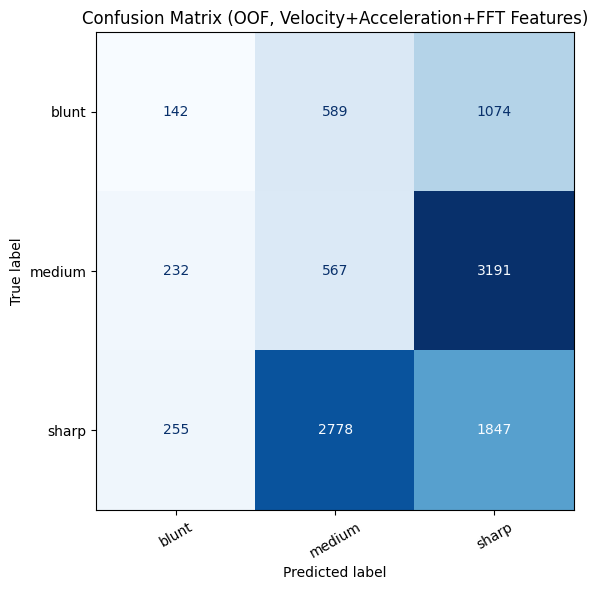


Class distribution (OOF):
 encoded_id class_name  oof_windows oof_pct
          0      blunt         1805   16.9%
          1     medium         3990   37.4%
          2      sharp         4880   45.7%


In [18]:
print("[phase=eval] Aggregated out-of-fold evaluation")

if len(oof_true) == 0:
    print("[warning] No OOF predictions found. Run training first.")
else:
    y_true = np.concatenate(oof_true).astype(int)
    y_pred = np.concatenate(oof_pred).astype(int)

    labels = list(range(len(label_encoder.classes_)))
    class_names = label_encoder.classes_.tolist()

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, labels=labels, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d", xticks_rotation=30)
    ax.set_title("Confusion Matrix (OOF, Velocity+Acceleration+FFT Features)")
    plt.tight_layout()
    plt.show()

    counts = pd.Series(y_true).value_counts().sort_index()
    total = len(y_true)
    rows = []
    for idx, class_name in enumerate(class_names):
        cnt = int(counts.get(idx, 0))
        pct = (cnt / total * 100.0) if total > 0 else 0.0
        rows.append({
            "encoded_id": idx,
            "class_name": class_name,
            "oof_windows": cnt,
            "oof_pct": f"{pct:.1f}%"
        })

    print("\nClass distribution (OOF):")
    print(pd.DataFrame(rows).to_string(index=False))